<a href="https://colab.research.google.com/github/tomassilva5/BigDataFlow/blob/main/BigDataColab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import plotly as py
import plotly.graph_objs as go
from google.colab import files
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats
from matplotlib.gridspec import GridSpecFromSubplotSpec
from scipy import stats
from matplotlib.gridspec import GridSpecFromSubplotSpec

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

from google.colab import files

py.offline.init_notebook_mode(connected=True)

%matplotlib inline

In [ ]:
iGov = pd.read_csv('Dataset-iGov.csv')
iGov = iGov.dropna()

In [ ]:
#convert text-based channels (e.g., 'Chatbot', 'Phone') into numeric codes
iGov['canal_encoded'] = iGov['canal_utilizado'].astype('category').cat.codes

#divide 'tempo_resposta' into 3 balanced groups: Fast, Medium, and Slow
iGov['tempo_categoria'] = pd.qcut(iGov['tempo_resposta'], q=3, labels=['Fast', 'Medium', 'Slow']) #0-33% (Fast), 33-66% (Medium), 66-100% (Slow)

print("Data Transformation Successful!")
iGov[['canal_utilizado', 'canal_encoded', 'tempo_resposta', 'tempo_categoria']].head()

Data Transformation Successful!


,canal_utilizado,canal_encoded,tempo_resposta,tempo_categoria
0,Presencial,4,36,Fast
1,Email,2,29,Fast
2,Telefone,5,38,Fast
3,Aplicacao_Movel,0,57,Medium
4,Portal,3,97,Slow


In [ ]:
iGov.head()

,id_registo,data_registo,unidade_organizacional,tipo_servico,indicador_si,taxa_resolucao,tempo_resposta,satisfacao_cidadao,volume_interacoes,canal_utilizado,taxa_abandono,erros_tecnicos,transparencia,feedback_cidadao,segmentacao_utilizador,area_tematica,indicador_kpi,canal_encoded,tempo_categoria
0,1,2024-04-12,Direcção De Serviços Financeiros,Telefone,83.02,87.37,36,3.8,368,Presencial,22.41,7,Sim,Processo Complicado,Empresa,Cultura,63.13,4,Fast
1,2,2024-12-14,Departamento De Inovação E Digitalização,Balcão Único,75.53,89.71,29,4.1,349,Email,14.87,1,Sim,Bom Serviço,Funcionário Público,Saúde,63.58,2,Fast
2,3,2024-09-27,Direcção De Recursos Humanos,Chatbot,85.73,75.96,38,3.3,398,Telefone,15.42,5,Não,Processo Complicado,Estudante,Inovação,73.64,5,Fast
3,4,2024-04-16,Departamento De Planeamento Estratégico,Email,78.33,73.82,57,3.4,74,Aplicacao_Movel,15.32,11,Sim,Processo Complicado,Funcionário Público,Digitalização,99.19,0,Medium
4,5,2024-03-12,Direcção De Recursos Humanos,Atendimento Presencial,81.82,70.41,97,4.7,487,Portal,7.47,4,Sim,Serviço Eficiente,Cidadão,Saúde,63.45,3,Slow


In [ ]:
iGov.columns

Index(['id_registo', 'data_registo', 'unidade_organizacional', 'tipo_servico',
       'indicador_si', 'taxa_resolucao', 'tempo_resposta',
       'satisfacao_cidadao', 'volume_interacoes', 'canal_utilizado',
       'taxa_abandono', 'erros_tecnicos', 'transparencia', 'feedback_cidadao',
       'segmentacao_utilizador', 'area_tematica', 'indicador_kpi',
       'canal_encoded', 'tempo_categoria'],
      dtype='object')

In [ ]:
len(iGov)

200

In [ ]:
df_analise = iGov.select_dtypes(include=[np.number]).drop(columns=['id_registo'], errors='ignore')

print("Statistics:")
resumo = df_analise.describe().T
resumo['median'] = df_analise.median()
resumo['mode'] = df_analise.mode().iloc[0]

resumo[['count', 'mean', 'median', 'mode', 'std', 'min', '25%', '50%', '75%', 'max']]

Statistics:


,count,mean,median,mode,std,min,25%,50%,75%,max
indicador_si,200.0,81.58325,82.390,63.65,12.373367,60.43,71.3925,82.390,92.5575,99.99
taxa_resolucao,200.0,82.90985,82.275,76.79,7.769950,70.41,75.8400,82.275,88.7925,97.72
tempo_resposta,200.0,58.73000,54.500,29.00,33.991088,1.00,29.7500,54.500,88.2500,118.00
satisfacao_cidadao,200.0,3.98550,4.000,3.50,0.591089,3.00,3.5000,4.000,4.5000,5.00
volume_interacoes,200.0,251.59000,251.000,49.00,142.126781,12.00,131.2500,251.000,366.5000,499.00
taxa_abandono,200.0,12.55550,13.325,8.98,6.568370,0.23,7.8975,13.325,16.5950,24.83
erros_tecnicos,200.0,7.03500,7.000,9.00,4.176240,0.00,3.0000,7.000,11.0000,14.00
indicador_kpi,200.0,75.16680,75.475,52.24,14.210823,50.11,63.0750,75.475,87.6100,99.99
canal_encoded,200.0,2.40500,2.000,4.00,1.713375,0.00,1.0000,2.000,4.0000,5.00


In [ ]:
#Additional Statistical Metrics

#Range
resumo['range'] = resumo['max'] - resumo['min']

#IQR
resumo['IQR'] = resumo['75%'] - resumo['25%']

#SEM
resumo['SEM'] = df_analise.sem()

print("Complementary Statistics (Performance & Precision):")
print(resumo[['mean', 'range', 'IQR', 'SEM']])

Complementary Statistics (Performance & Precision):
                         mean   range       IQR        SEM
indicador_si         81.58325   39.56   21.1650   0.874929
taxa_resolucao       82.90985   27.31   12.9525   0.549418
tempo_resposta       58.73000  117.00   58.5000   2.403533
satisfacao_cidadao    3.98550    2.00    1.0000   0.041796
volume_interacoes   251.59000  487.00  235.2500  10.049881
taxa_abandono        12.55550   24.60    8.6975   0.464454
erros_tecnicos        7.03500   14.00    8.0000   0.295305
indicador_kpi        75.16680   49.88   24.5350   1.004857
canal_encoded         2.40500    5.00    3.0000   0.121154


Generating Dashboard...


/tmp/ipython-input-176/17234119.py:95: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



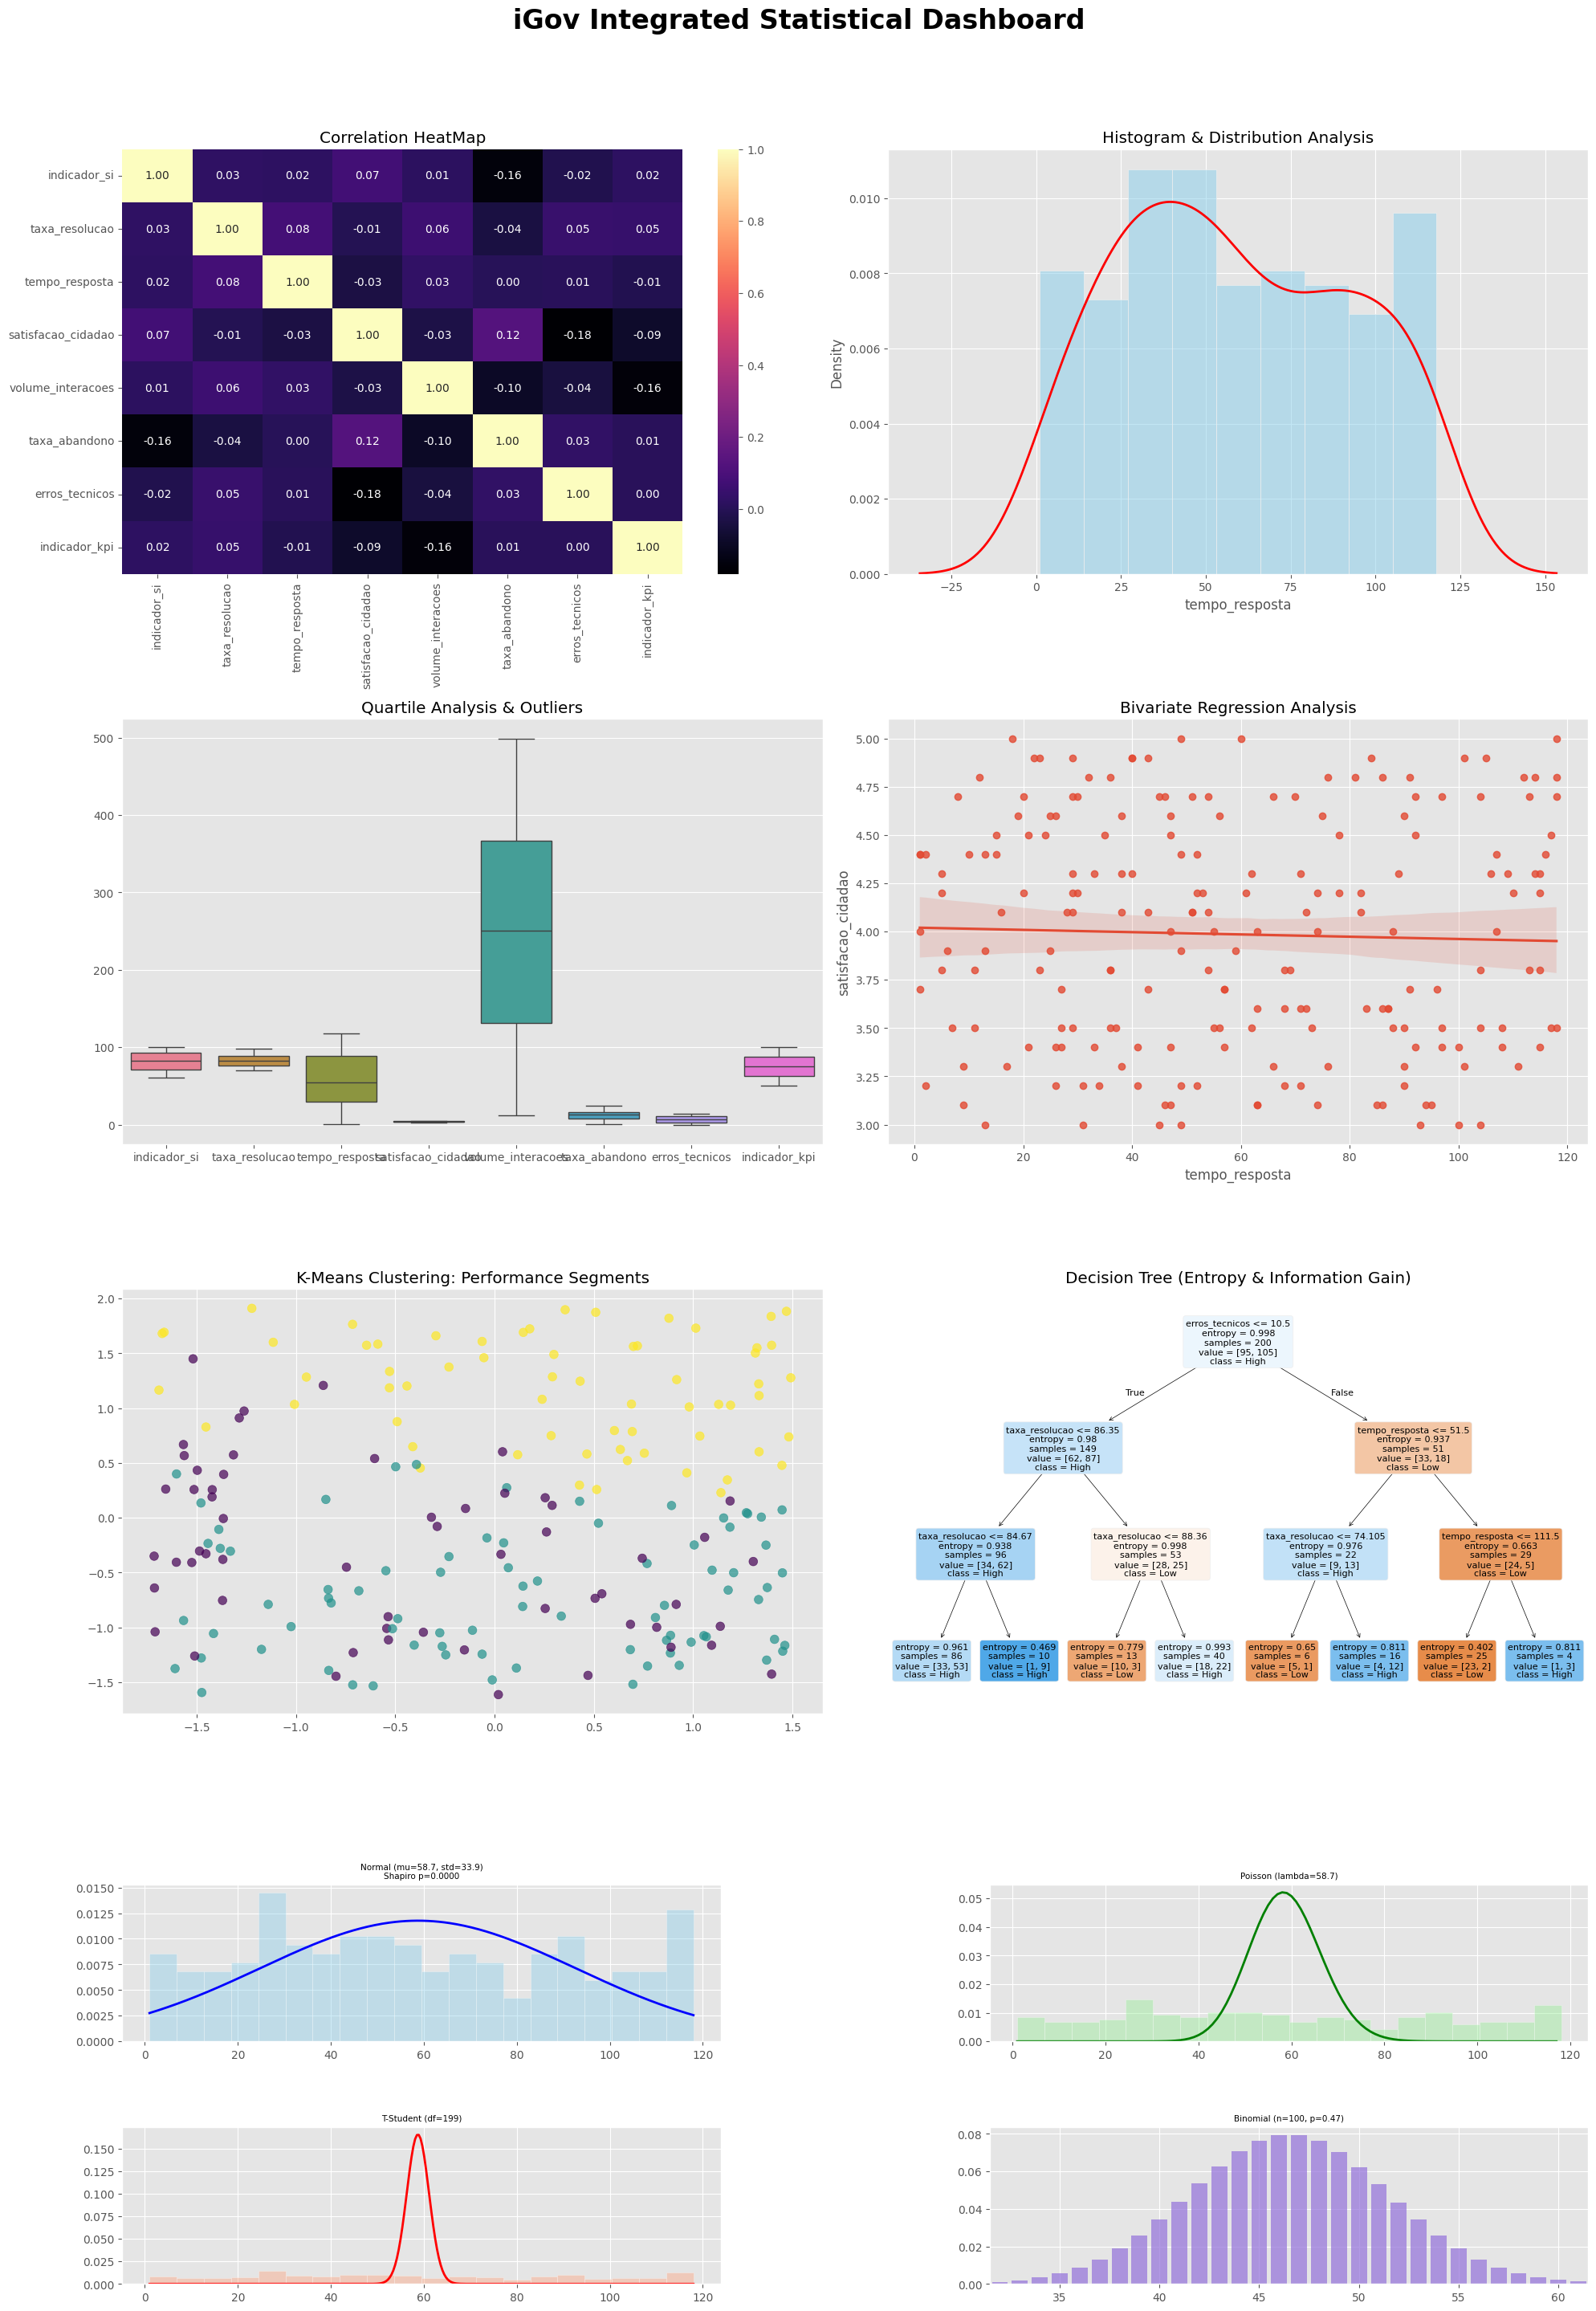

Generating Scatterplot Matrix...


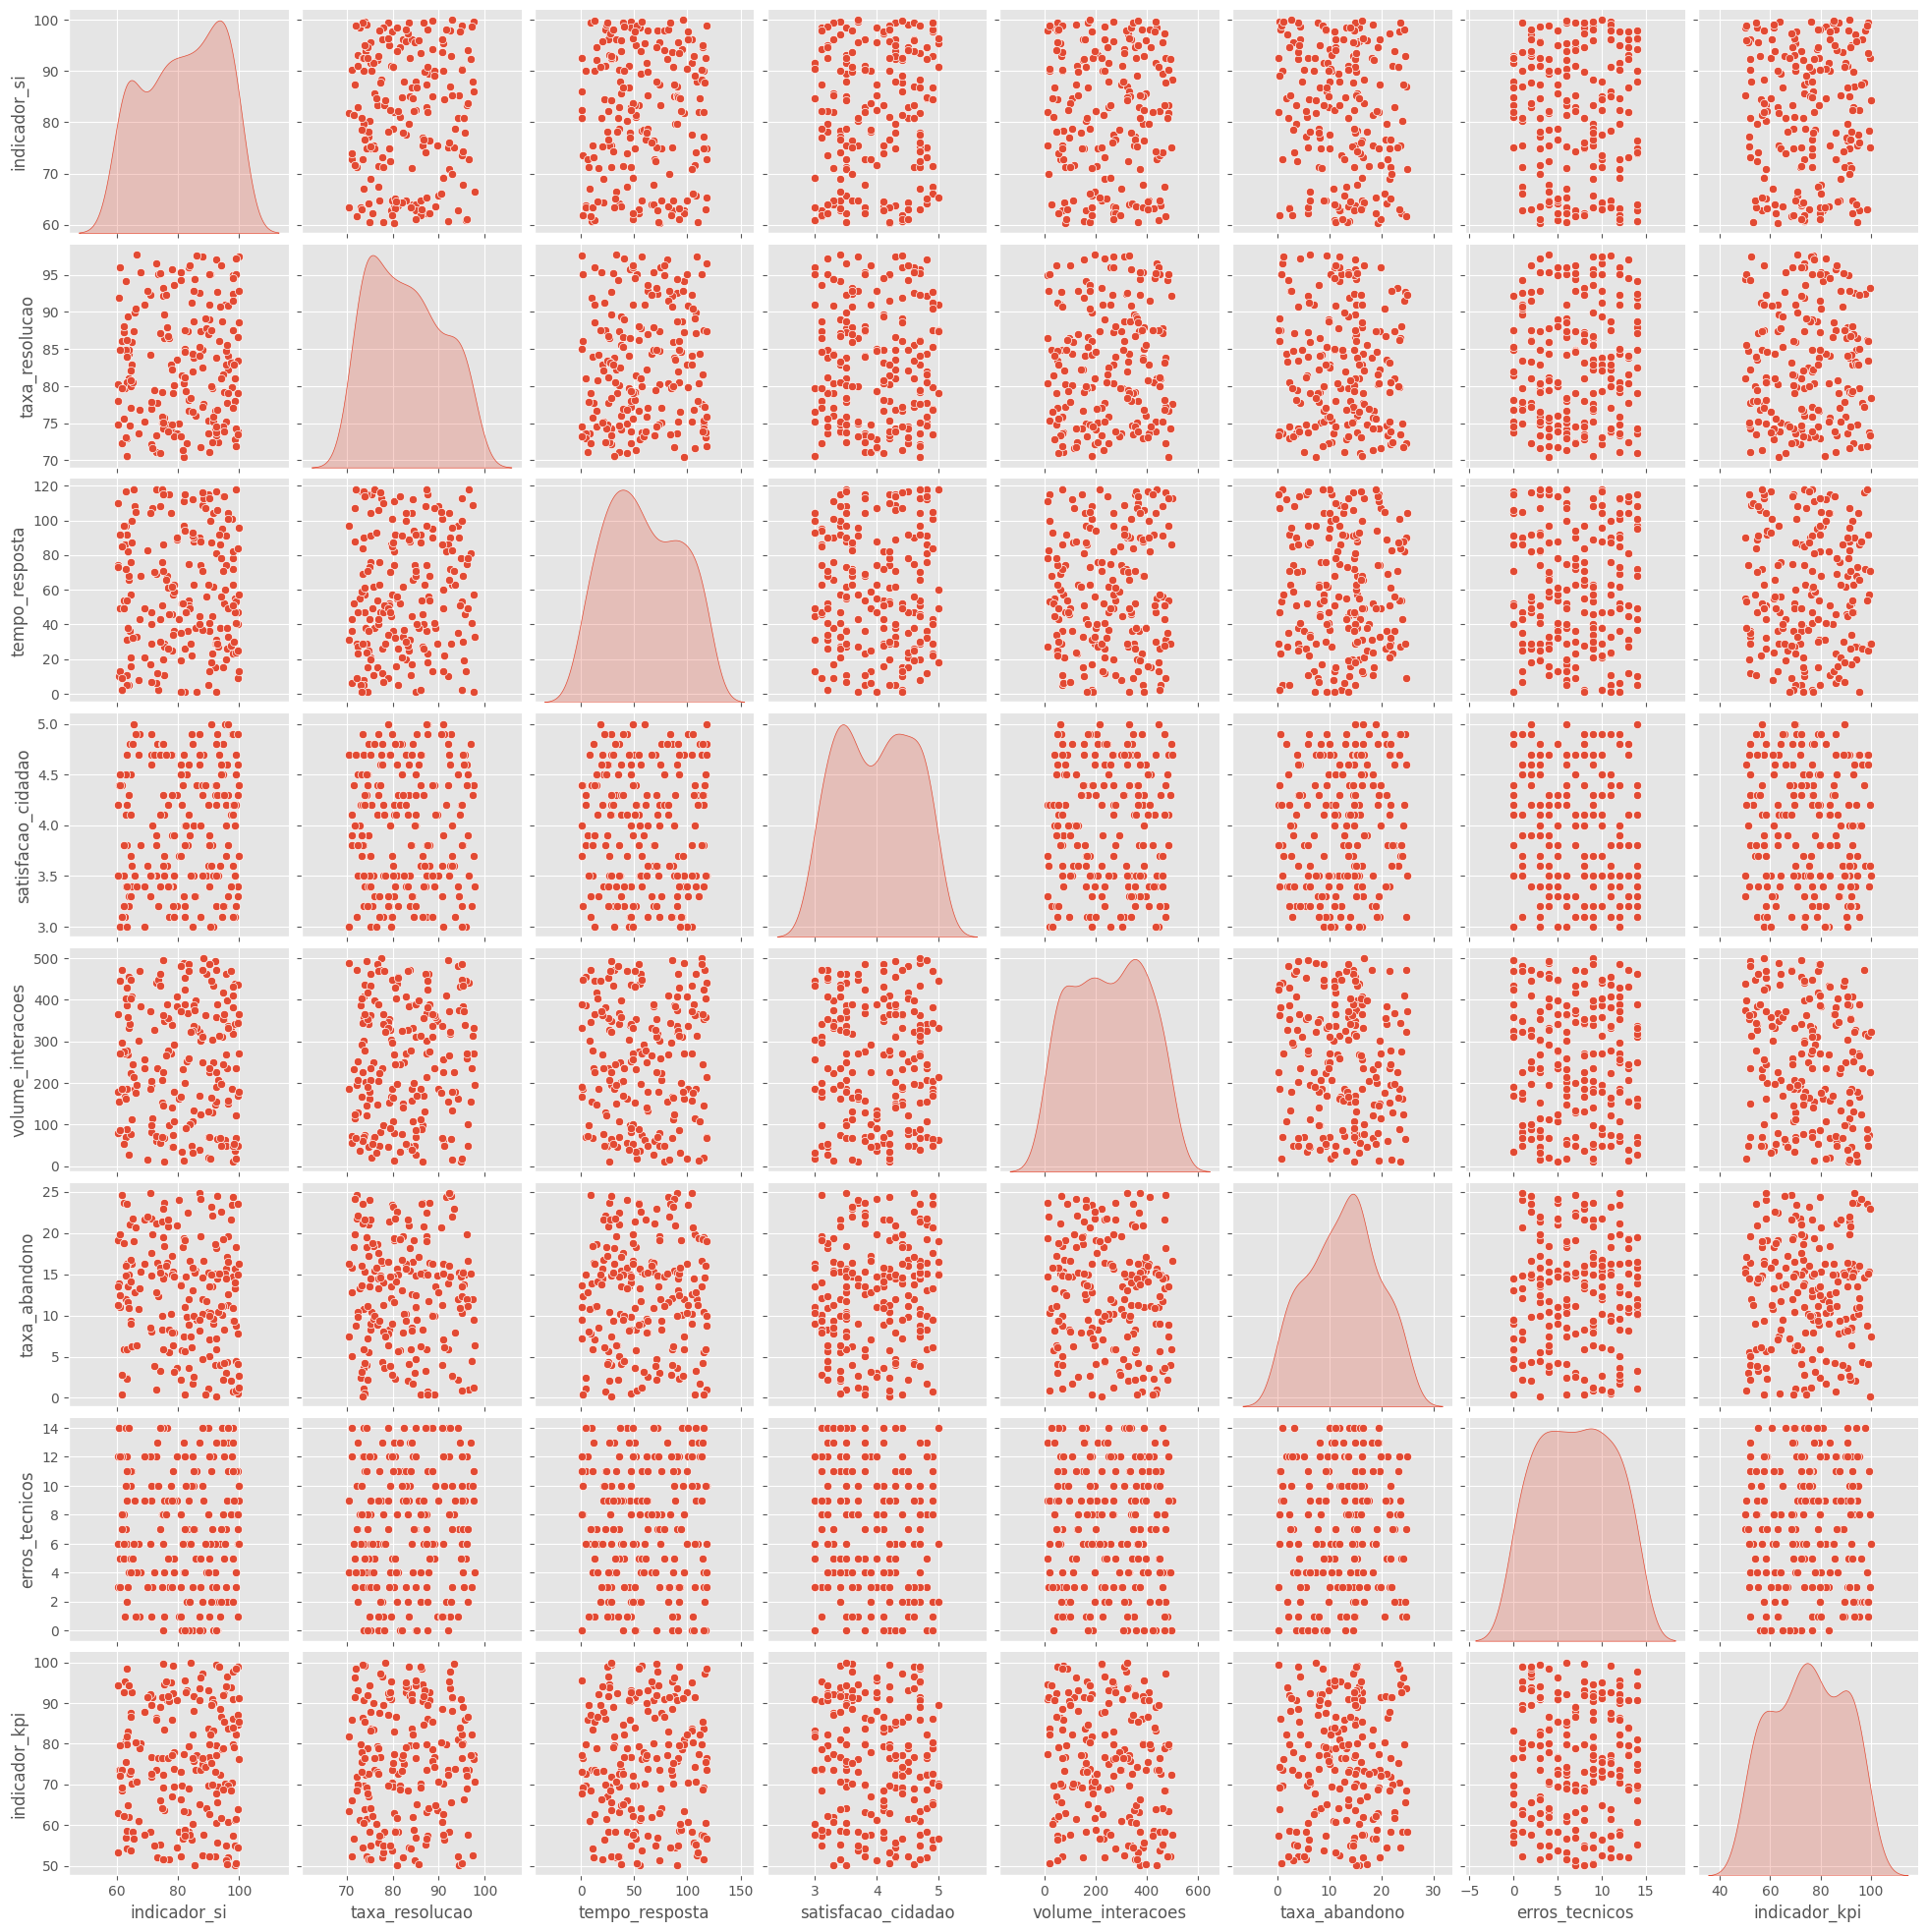


Attribute Importance (Entropy Gain):
taxa_resolucao    0.414863
tempo_resposta    0.402258
erros_tecnicos    0.182879
indicador_si      0.000000
dtype: float64

Analysis for tempo_resposta:
  Skewness: 0.1316
  Kurtosis: -1.1278


Analysis for satisfacao_cidadao:
  Skewness: -0.0004
  Kurtosis: -1.2682



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [ ]:
print("Generating Dashboard...")

numeric_iGov = iGov.select_dtypes(include=[np.number]).drop(columns=['id_registo'], errors='ignore')

plt.style.use('ggplot')
fig = plt.figure(figsize=(20, 30))
plt.suptitle('iGov Integrated Statistical Dashboard', fontsize=24, fontweight='bold')

#HeatMap
plt.subplot(4, 2, 1)
sb.heatmap(numeric_iGov.corr(), annot=True, cmap='magma', fmt='.2f')
plt.title('Correlation HeatMap')

#Histogram & KDE
plt.subplot(4, 2, 2)
sb.histplot(numeric_iGov['tempo_resposta'], kde=True, color='skyblue', stat="density")
sb.kdeplot(numeric_iGov['tempo_resposta'], color='red', linewidth=2)
plt.title('Histogram & Distribution Analysis')

#Boxplot (Quartiles)
plt.subplot(4, 2, 3)
sb.boxplot(data=numeric_iGov)
plt.title('Quartile Analysis & Outliers')

#Bivariate Regression
plt.subplot(4, 2, 4)
sb.regplot(x='tempo_resposta', y='satisfacao_cidadao', data=iGov)
plt.title('Bivariate Regression Analysis')

#K-Means Clustering
plt.subplot(4, 2, 5)
cluster_data = numeric_iGov[['indicador_si', 'taxa_resolucao', 'tempo_resposta']].dropna()
scaled_features = StandardScaler().fit_transform(cluster_data)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_features)
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=clusters, cmap='viridis', s=60, alpha=0.7)
plt.title('K-Means Clustering: Performance Segments')

#Decision Tree
# Definindo alvo (satisfacao alta/baixa com base na mediana)
media_sat = iGov['satisfacao_cidadao'].median()
iGov['satisfacao_binaria'] = (iGov['satisfacao_cidadao'] >= media_sat).astype(int)

X = numeric_iGov[['tempo_resposta', 'taxa_resolucao', 'erros_tecnicos', 'indicador_si']]
y = iGov['satisfacao_binaria']

clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf.fit(X, y)

plt.subplot(4, 2, 6)
plot_tree(clf, feature_names=X.columns, class_names=['Low', 'High'], filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree (Entropy & Information Gain)')

#GridSpec
col = numeric_iGov['tempo_resposta'].dropna()
mu, std = stats.norm.fit(col)
lambda_est = col.mean()
df_t = len(col) - 1
x = np.linspace(col.min(), col.max(), 300)

gs_main = fig.add_gridspec(4, 2, hspace=0.45, wspace=0.35)
gs_sub = GridSpecFromSubplotSpec(2, 2, subplot_spec=gs_main[3, 0:2], hspace=0.55, wspace=0.45)

#Normal
ax_n = fig.add_subplot(gs_sub[0, 0])
ax_n.hist(col, bins=20, density=True, alpha=0.4, color='skyblue', edgecolor='white')
ax_n.plot(x, stats.norm.pdf(x, mu, std), 'b-', linewidth=2)
_, p_sw = stats.shapiro(col)
ax_n.set_title(f'Normal (mu={mu:.1f}, std={std:.1f})\nShapiro p={p_sw:.4f}', fontsize=7.5)

#Poisson
ax_p = fig.add_subplot(gs_sub[0, 1])
k = np.arange(int(col.min()), int(col.max()))
ax_p.hist(col, bins=20, density=True, alpha=0.4, color='lightgreen', edgecolor='white')
ax_p.plot(k, stats.poisson.pmf(k, lambda_est), 'g-', linewidth=2)
ax_p.set_title(f'Poisson (lambda={lambda_est:.1f})', fontsize=7.5)

#T-Student
ax_t = fig.add_subplot(gs_sub[1, 0])
t_se = stats.sem(col)
x_t = (x - mu) / t_se
ax_t.hist(col, bins=20, density=True, alpha=0.4, color='lightsalmon', edgecolor='white')
ax_t.plot(x, stats.t.pdf(x_t, df_t) / t_se, 'r-', linewidth=2)
ax_t.set_title(f'T-Student (df={df_t})', fontsize=7.5)

#Binomial
ax_b = fig.add_subplot(gs_sub[1, 1])
p_bin = (col > mu).mean()
n_bin = 100
k_bin = np.arange(0, n_bin + 1)
ax_b.bar(k_bin, stats.binom.pmf(k_bin, n_bin, p_bin), color='mediumpurple', alpha=0.7, width=0.8)
ax_b.set_xlim([n_bin * p_bin - 15, n_bin * p_bin + 15])
ax_b.set_title(f'Binomial (n={n_bin}, p={p_bin:.2f})', fontsize=7.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#Scatterplot MatrixA
print("Generating Scatterplot Matrix...")
sb.pairplot(numeric_iGov, diag_kind='kde')
plt.show()

#Information Gain
importancias = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nAttribute Importance (Entropy Gain):")
print(importancias)

#Shape Analysis (Skewness & Kurtosis)

variables_to_analyze = ['tempo_resposta', 'satisfacao_cidadao']

shape_text = ""

for var in variables_to_analyze:
    v_data = numeric_iGov[var].dropna()
    sk = v_data.skew()
    kt = v_data.kurt()

    shape_text += f"{var.replace('_', ' ').title()}: Skew={sk:.2f}, Kurt={kt:.2f}  |  "

    print(f"\nAnalysis for {var}:")
    print(f"  Skewness: {sk:.4f}")
    print(f"  Kurtosis: {kt:.4f}\n")

fig.text(0.5, 0.02, shape_text.strip(" | "),
         ha='center', fontsize=11, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
fig.savefig('dashboard_igov.png', dpi=300, bbox_inches='tight')
files.download('dashboard_igov.png')

In [ ]:
iGov.to_csv('iGov_Final_Analysis.csv', index=False)

files.download('iGov_Final_Analysis.csv')

NameError: name 'iGov' is not defined

In [ ]:
#ydata AI
!pip install ydata-profiling
from ydata_profiling import ProfileReport

iGov = pd.read_csv("Dataset-iGov.csv")

profile = ProfileReport(iGov, title="iGov Dataset Exploratory Analysis", explorative=True)

profile.to_file("report_igov.html")

files.download("report_igov.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:00<00:00, 40.89it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

TARGET = "satisfacao_cidadao"
FEATURES = ['tempo_resposta', 'taxa_resolucao', 'erros_tecnicos', "volume_interacoes", "taxa_abandono"]

X = numeric_iGov[FEATURES]
y = numeric_iGov[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def build_igov_pipeline(model):
    return Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

mlflow.set_experiment("iGov_Satisfaction_Analysis")
models_to_run = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "DecisionTree": DecisionTreeRegressor(max_depth=3, random_state=42)
}

print("TASK 2: MLFLOW MODEL ANALYSIS DASHBOARD")
results_list = []
trained_pipelines = {}

for name, model in models_to_run.items():
    with mlflow.start_run(run_name=name):
        pipe = build_igov_pipeline(model)
        pipe.fit(X_train, y_train)
        trained_pipelines[name] = pipe

        preds = pipe.predict(X_test)
        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)

        mlflow.log_metrics({"r2": r2, "mae": mae})
        results_list.append({"Model": name, "R2 Score": r2, "MAE": mae})

display(pd.DataFrame(results_list))

TASK 2: MLFLOW MODEL ANALYSIS DASHBOARD


,Model,R2 Score,MAE
0,LinearRegression,0.098390,0.499324
1,RandomForest,-0.181015,0.546775
2,DecisionTree,-0.310437,0.584545


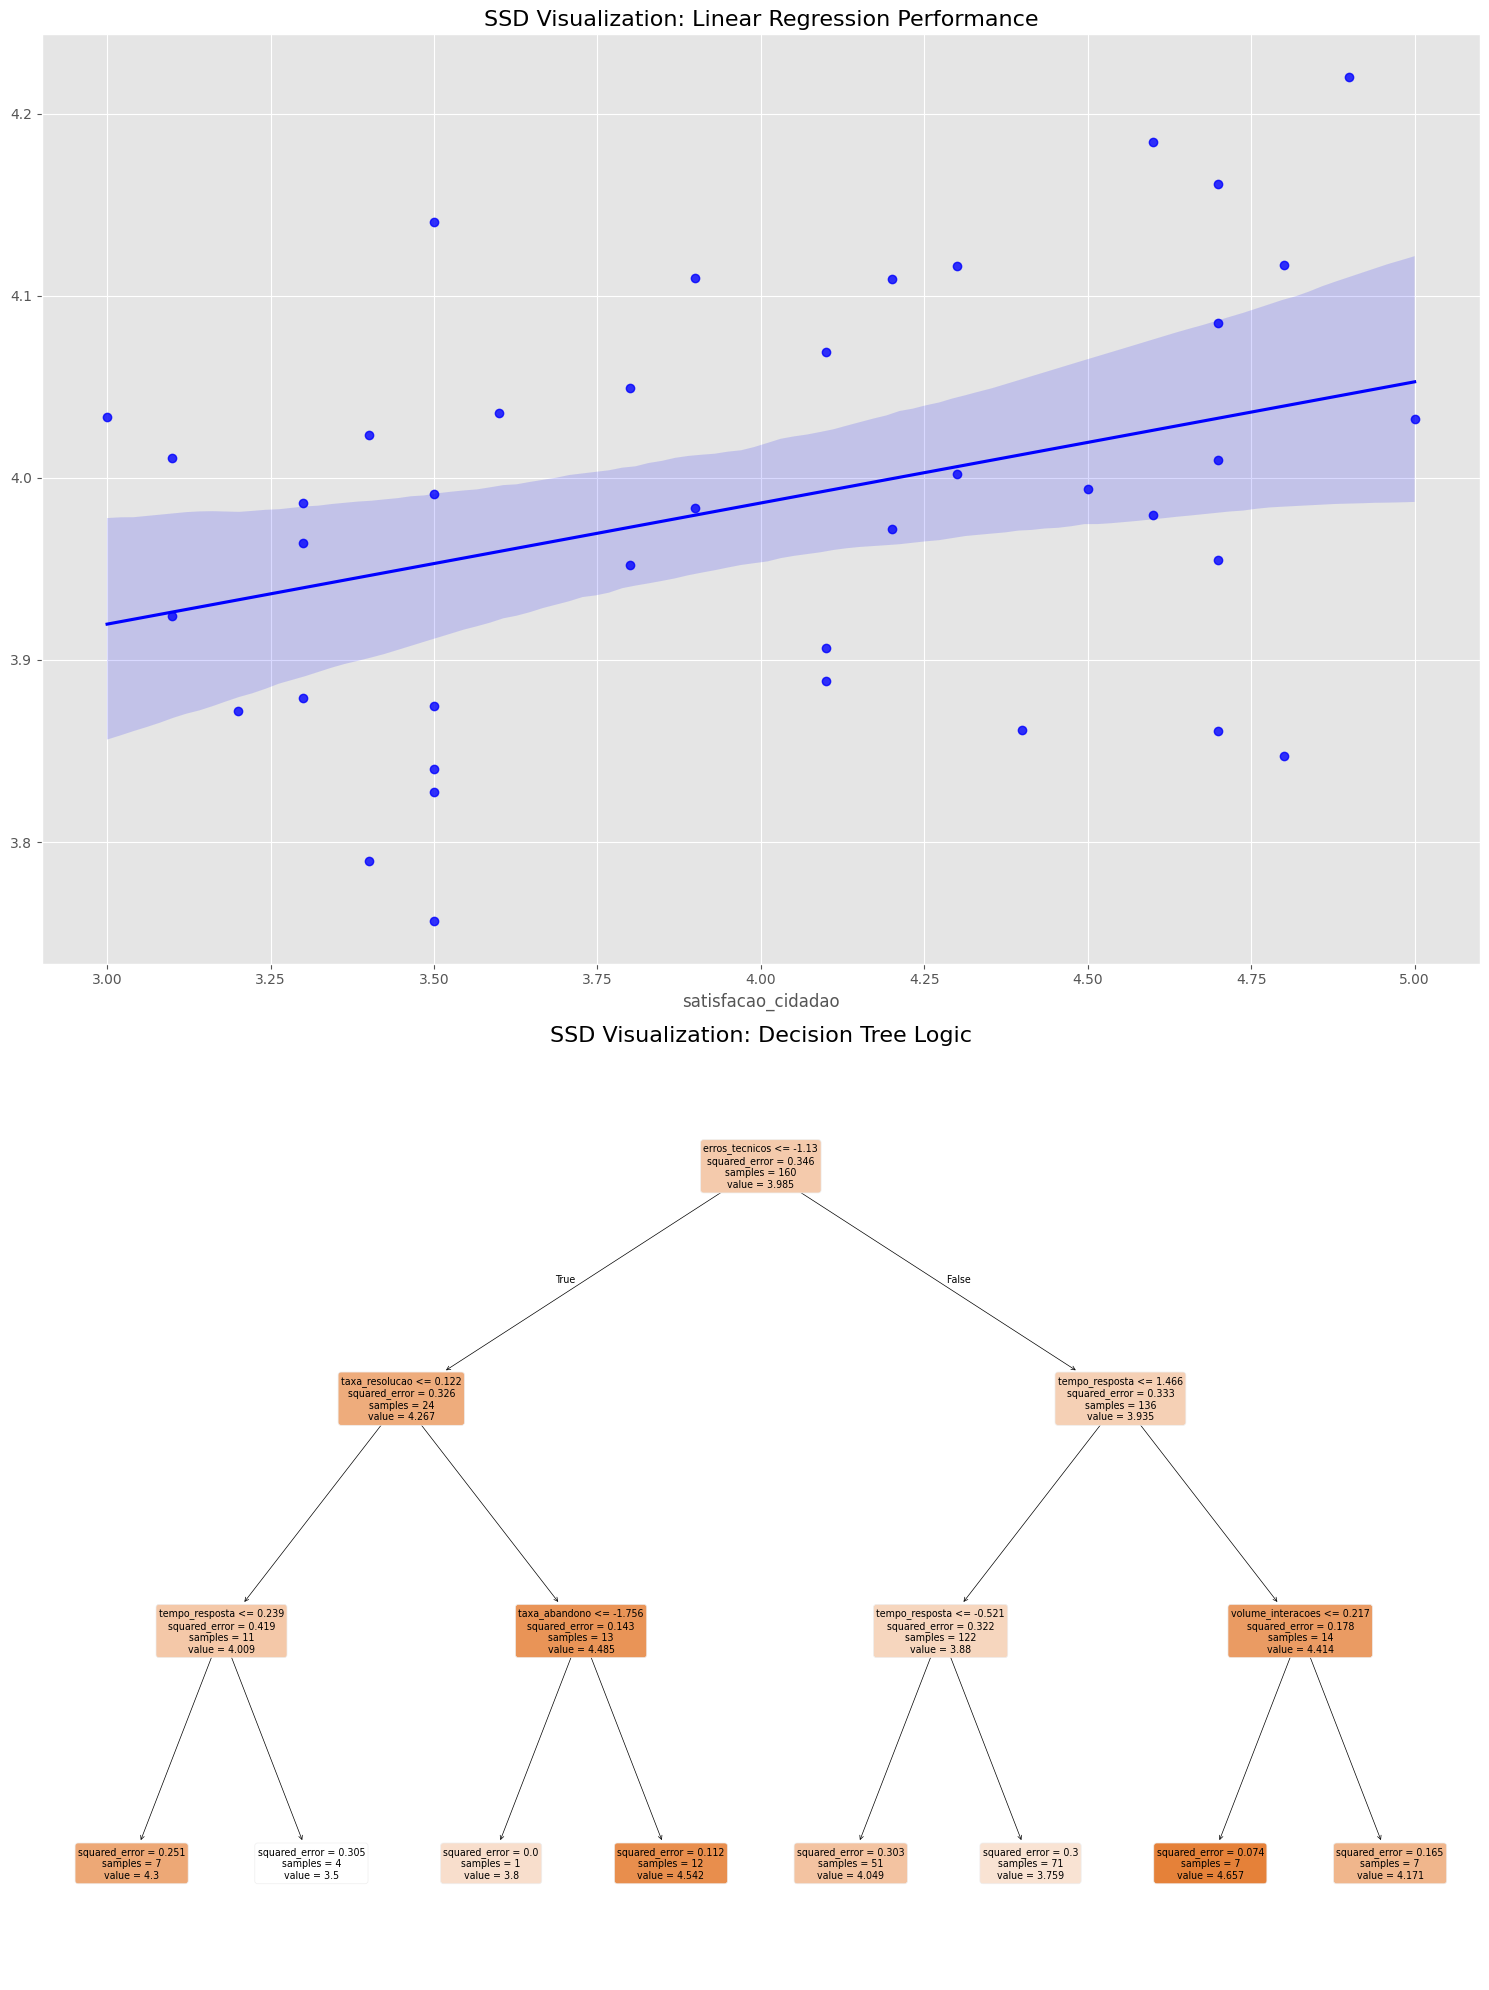

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import seaborn as sb

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 20))

#Linear Regression
sb.regplot(x=y_test, y=trained_pipelines["LinearRegression"].predict(X_test), ax=ax1, color='blue')
ax1.set_title("SSD Visualization: Linear Regression Performance", fontsize=16)

#Decision Tree Structure
plot_tree(trained_pipelines["DecisionTree"].named_steps['model'],
          feature_names=FEATURES, filled=True, rounded=True, ax=ax2)
ax2.set_title("SSD Visualization: Decision Tree Logic", fontsize=16)

plt.tight_layout()
filename = "IGOV_MLFLOW_VISUALIZATION.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

#download
files.download(filename)

In [ ]:
def ssd_prediction_form(time, resolution, errors, volume, abandonment):
    input_data = pd.DataFrame([[time, resolution, errors, volume, abandonment]],
                              columns=FEATURES)

    prediction = trained_pipelines["LinearRegression"].predict(input_data)

    print(f"iGov DECISION SUPPORT SYSTEM (SSD) ")
    print(f"Operational Scenario:")
    print(f" > Response Time: {time} min")
    print(f" > Resolution Rate: {resolution}%")
    print(f" > Technical Errors: {errors}")
    print(f" > Interaction Volume: {volume} cases")
    print(f" > Abandonment Rate: {abandonment}%")
    print("-" * 45)
    print(f"PREDICTED SATISFACTION: {prediction[0]:.2f} / 5.00")

ssd_prediction_form(time=20, resolution=95, errors=0, volume=100, abandonment=2)

iGov DECISION SUPPORT SYSTEM (SSD) 
Operational Scenario:
 > Response Time: 20 min
 > Resolution Rate: 95%
 > Technical Errors: 0
 > Interaction Volume: 100 cases
 > Abandonment Rate: 2%
---------------------------------------------
PREDICTED SATISFACTION: 4.09 / 5.00
